In [1]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten,Conv2D,MaxPool2D,ZeroPadding2D,Dense,Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam


In [2]:
data_generator=ImageDataGenerator(rescale=1./255,zoom_range=0.4,horizontal_flip=True,validation_split=0.2,rotation_range=50,width_shift_range=0.3,height_shift_range=0.3,shear_range=0.4,fill_mode='nearest')
train=data_generator.flow_from_directory('pet_train/',target_size=(200,200),batch_size=50,class_mode='binary')

Found 7974 images belonging to 2 classes.


In [3]:
test=data_generator.flow_from_directory('pet_test/',target_size=(200,200),batch_size=50,class_mode='binary')


Found 1035 images belonging to 2 classes.


In [4]:
model=Sequential()
model.add(Conv2D(32,(3,3),
                 activation='relu',
                 input_shape=(200,200,3)
                 ,padding='same'))
model.add(MaxPool2D(pool_size=(2,2)))
model.add(Flatten())
model.add(Dropout(0.5))

model.add(Dense(1,activation='sigmoid'))


C:\Users\LOQ\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [5]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 200, 200, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 100, 100, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 320000)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 320000)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │       320,001 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 320,897 (1.22 MB)

 Trainable params: 320,897 (1.22 MB)

 Non-trainable params: 0 (0.00 B)

In [6]:
import os
from PIL import Image

folder_path = 'pet_train/'
extensions = []

for fldr in os.listdir(folder_path):
    sub_folder_path = os.path.join(folder_path, fldr)
    for filee in os.listdir(sub_folder_path):
        file_path = os.path.join(sub_folder_path, filee)
        print('** Path: {} **'.format(file_path), end="\r", flush=True)
        try:
            im = Image.open(file_path)
            rgb_im = im.convert('RGB')
            ext = filee.split('.')[-1].lower()
            if ext not in extensions:
                extensions.append(ext)
        except Exception as e:
            print(f"\n error: {file_path} — {e}")

C:\Users\LOQ\AppData\Local\Programs\Python\Python313\Lib\site-packages\PIL\TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


In [7]:
model.compile(optimizer=Adam(),  loss='binary_crossentropy',metrics=['accuracy'])

In [8]:
history=model.fit(train,steps_per_epoch=len(train),epochs=30,validation_data=test,validation_steps=len(test))

Epoch 1/30
160/160 ━━━━━━━━━━━━━━━━━━━━ 56s 340ms/step - accuracy: 0.5673 - loss: 0.8069 - val_accuracy: 0.5855 - val_loss: 0.6539
Epoch 2/30
160/160 ━━━━━━━━━━━━━━━━━━━━ 55s 342ms/step - accuracy: 0.6110 - loss: 0.6503 - val_accuracy: 0.6019 - val_loss: 0.6562
Epoch 3/30
160/160 ━━━━━━━━━━━━━━━━━━━━ 50s 313ms/step - accuracy: 0.6090 - loss: 0.6514 - val_accuracy: 0.5662 - val_loss: 0.6759
Epoch 4/30
160/160 ━━━━━━━━━━━━━━━━━━━━ 52s 328ms/step - accuracy: 0.6012 - loss: 0.6515 - val_accuracy: 0.5778 - val_loss: 0.6596
Epoch 5/30
160/160 ━━━━━━━━━━━━━━━━━━━━ 53s 332ms/step - accuracy: 0.6158 - loss: 0.6520 - val_accuracy: 0.5865 - val_loss: 0.6627
Epoch 6/30
160/160 ━━━━━━━━━━━━━━━━━━━━ 53s 333ms/step - accuracy: 0.6160 - loss: 0.6489 - val_accuracy: 0.6213 - val_loss: 0.6491
Epoch 7/30
160/160 ━━━━━━━━━━━━━━━━━━━━ 54s 339ms/step - accuracy: 0.6225 - loss: 0.6470 - val_accuracy: 0.6329 - val_loss: 0.6321
Epoch 8/30
160/160 ━━━━━━━━━━━━━━━━━━━━ 116s 726ms/step - accuracy: 0.6364 - loss: 

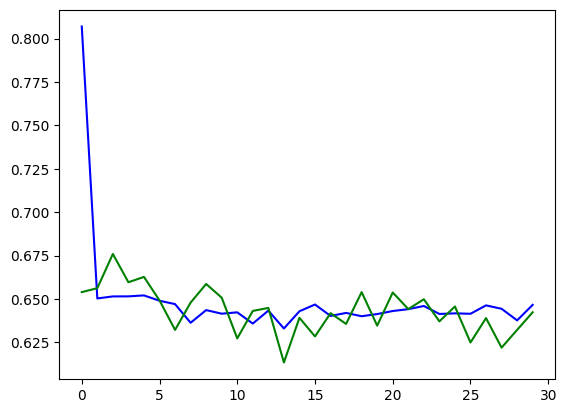

In [12]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'],color='blue',label="train data")
plt.plot(history.history['val_loss'],color='green',label="validation data")

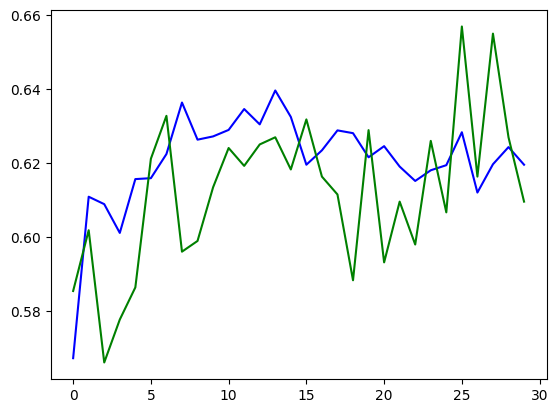

In [13]:
plt.plot(history.history['accuracy'], color='blue', label="train data")
plt.plot(history.history['val_accuracy'], color='green', label="validation data")

In [11]:
model.save("cat_dog.keras")